In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# Get the absolute path of the script
current_dir = os.getcwd()

# Move up two levels to the project root
project_root = os.path.abspath(os.path.join(current_dir, "../.."))

# Construct the CSV path
csv_path = os.path.join(project_root, "data", "reviews_labeled.csv")

In [ ]:
df = pd.read_csv(csv_path)
# KEEP ONLY LEGITIMATE REVIEWS
df = df[df['Authenticity'] == 'Legitimate']
# remove columns that have unnamed in the name
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# remove white space from column names
df.columns = df.columns.str.strip()

# general info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017 entries, 0 to 1079
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   source          1017 non-null   object
 1   size            1017 non-null   object
 2   comment         1017 non-null   object
 3   original        1017 non-null   object
 4   Satisfaction    1017 non-null   int64 
 5   Authenticity    1017 non-null   object
 6   Type            1017 non-null   object
 7   needs_response  1017 non-null   object
 8   Category        1017 non-null   object
 9   Impact          1017 non-null   object
 10  Language        1017 non-null   object
 11  Emotion         1017 non-null   object
dtypes: int64(1), object(11)
memory usage: 103.3+ KB


In [ ]:
# find duplicate rows in the column comment
duplicates = df[df.duplicated('original')]
print(duplicates.shape)

(12, 12)


In [ ]:
duplicates.head(22)

,source,size,comment,original,Satisfaction,Authenticity,Type,needs_response,Category,Impact,Language,Emotion
136,Yalidine Maabouda Setif,short,I didn't really like the service,J'ai pas trop aimé le service,1,Legitimate,Complaint,Yes,"Customer Service, Product Quality / Food Quality",Low Impact,French,Disappointment
224,Yalidine Hidhab Setif,short,Impeccable service,Service impeccable,5,Legitimate,Praise,No,Customer Service,No issue,French,Satisfaction
508,Attraction Park Setif,short,Wonderful garden,Wonderful garden,5,Legitimate,Praise,No,Customer Service,No issue,English,Satisfaction
517,Attraction Park Setif,short,Very beautiful,Very beautiful,5,Legitimate,Praise,No,Customer Service,No issue,English,Satisfaction
518,Attraction Park Setif,short,Very beautiful,Very beautiful,5,Legitimate,Praise,No,Customer Service,No issue,English,Satisfaction
519,Attraction Park Setif,short,Very beautiful,Very beautiful,5,Legitimate,Praise,No,Customer Service,No issue,English,Satisfaction
765,EMS SETIF,short,Impeccable service,Service impeccable,5,Legitimate,Praise,No,Customer Service,No issue,French,Gratitude
823,DHL Setif,short,Fast service,Service rapide,5,Legitimate,Praise,No,Customer Service,No issue,French,Satisfaction
882,La Citadelle,short,Disastrous services,خدمات كارثية,1,Legitimate,Complaint,Yes,Customer Service,High,Arabic,Anger
1001,La Citadelle,short,magnificence,روعة,5,Legitimate,Praise,No,Customer Service,No issue,Arabic,Excitement


In [ ]:
df = df.drop_duplicates('original')
df.shape

(1005, 12)

## Visualization

Text(0.5, 1.0, 'Distribution of Review Types')

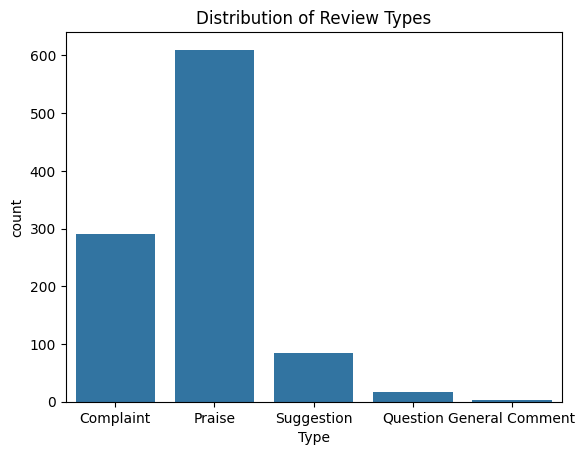

In [ ]:
sns.countplot(x='Type', data=df)
plt.title('Distribution of Review Types')

In [ ]:
df.columns

Index(['source', 'size', 'comment', 'original', 'Satisfaction', 'Authenticity',
       'Type', 'needs_response', 'Category', 'Impact', 'Language', 'Emotion'],
      dtype='object')

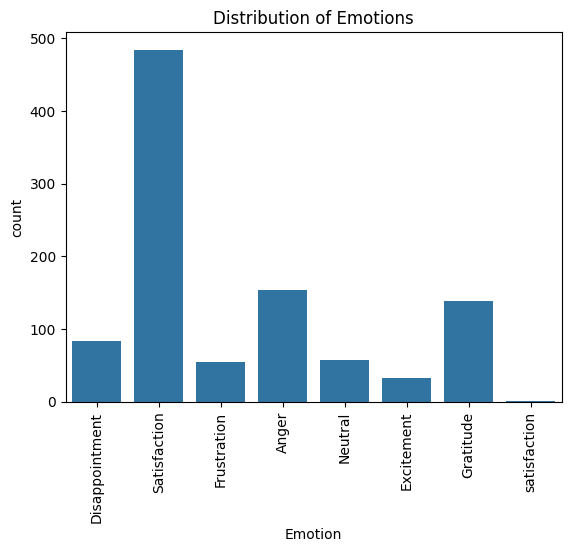

In [ ]:
sns.countplot(x='Emotion', data=df)
plt.title('Distribution of Emotions')
plt.xticks(rotation=90)
plt.show()

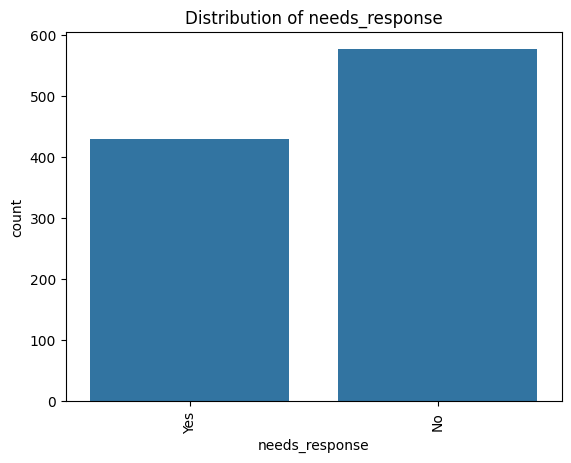

In [ ]:
sns.countplot(x='needs_response', data=df)
plt.title('Distribution of needs_response')
plt.xticks(rotation=90)
plt.show()

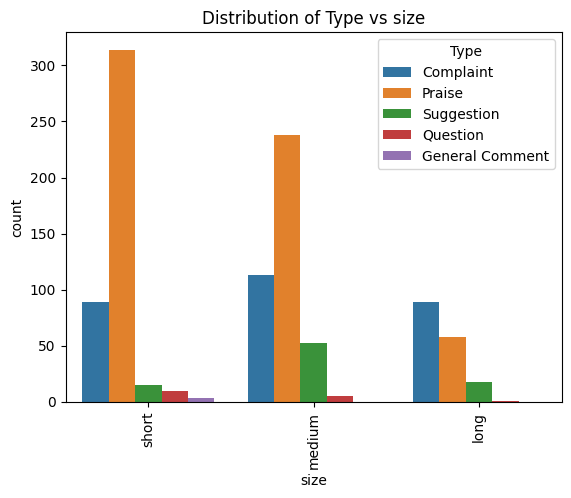

In [ ]:
sns.countplot(x='size', data=df, hue='Type')
plt.title('Distribution of Type vs size')
plt.xticks(rotation=90)
plt.show()

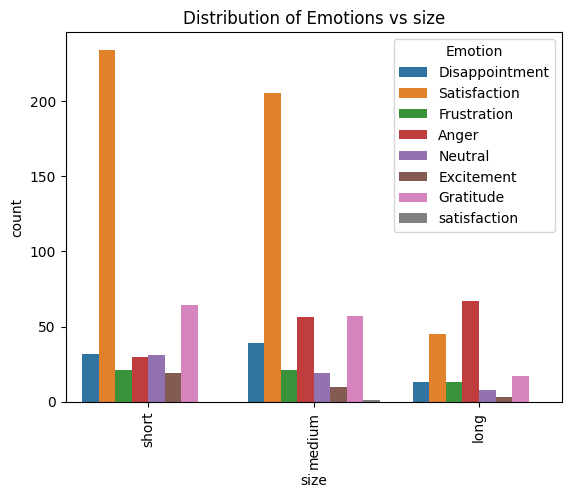

In [ ]:
sns.countplot(x='size', data=df, hue='Emotion')
plt.title('Distribution of Emotions vs size')
plt.xticks(rotation=90)
plt.show()

In [2]:
sns.countplot(x='Language', data=df, order=df['Language'].value_counts().index)
plt.title('Distribution of Language')
plt.xticks(rotation=90)
plt.show()

NameError: name 'sns' is not defined

In [15]:
df['Language'].value_counts()

Language
French                   450
English                  236
Arabic                   230
Derja                     41
Arabic, Derja             12
Derja, Arabic              6
Derja, French              4
French, Arabic             4
English, Derja             3
French, Derja              3
Arabic, English            3
English, Arabic            2
Arabic, French             2
Korean                     2
Chinese                    1
Italian                    1
Turkish                    1
Russian                    1
Arabic, Derja, French      1
Spanish                    1
French, English            1
Name: count, dtype: int64

## text data quality

In [29]:
df.iloc[2]['original']

'Over rated\nطوابل لازقين فبعضاهم و مزيتتين ميش نظاف\nماكلة مزية ، و ذوق عادي تستنا بزاف باه تجيك الطلبية'

In [ ]:
import re
import unicodedata

def clean_text(text):
    # Normalize Unicode characters (fix accented letters, etc.)
    text = unicodedata.normalize("NFKC", text)

    # Remove emojis and special symbols
    text = re.sub(r"[^\w\s,.!?]", "", text)  # Keeps punctuation like ,.!?

    # Remove excessive spaces and new lines
    text = re.sub(r"\s+", " ", text).strip()

    return text

'Over rated طوابل لازقين فبعضاهم و مزيتتين ميش نظاف ماكلة مزية و ذوق عادي تستنا بزاف باه تجيك الطلبية'

In [31]:
df['cleaned'] = df['original'].apply(clean_text)

In [32]:
df.to_csv(os.path.join(project_root, "data", "reviews_labeled_cleaned.csv"), index=False)